# Part 3 - Analysis

## Data Loading

In [1]:
#### Imports
import duckdb
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
#### Connect to database
con = duckdb.connect()

In [3]:
#### Check current working directory
import os
os.getcwd()

'C:\\Users\\alice\\OneDrive\\Desktop\\Admin\\Alice Documents\\job-search\\assignments\\260622_HA'

In [4]:
#### Load joined dataframe and check shape

df = con.execute("""
    SELECT
        d.city,
        d.month,
        d.landlord_type,
        d.listing_type,
        d.visitors,
        d.searchers,
        d.applicants,
        o.bookings,
        o.revenue_eur,
        m.commission_rate_pct,
        m.booking_fee_eur,
        m.avg_revenue_per_booking_eur,
        m.avg_rent_eur,
        s.available_listings,
        s.created_listings
    FROM 'data_demand.csv' d
    LEFT JOIN 'data_key_outcomes.csv' o
        ON d.city = o.city
        AND d.month = o.month
        AND d.landlord_type = o.landlord_type
        AND d.listing_type = o.listing_type
    LEFT JOIN 'data_monetisation.csv' m
        ON d.city = m.city
        AND d.month = m.month
        AND d.landlord_type = m.landlord_type
        AND d.listing_type = m.listing_type
    LEFT JOIN 'data_supply.csv' s
        ON d.city = s.city
        AND d.month = s.month
        AND d.landlord_type = s.landlord_type
        AND d.listing_type = s.listing_type
""").df()

# df.shape
df

,city,month,landlord_type,listing_type,visitors,searchers,applicants,bookings,revenue_eur,commission_rate_pct,booking_fee_eur,avg_revenue_per_booking_eur,avg_rent_eur,available_listings,created_listings
0,Berlin,2023-01-01,PBSA,Room,6413,1903,397,132,18639,13.5,50.0,145.31,706,386,30
1,Berlin,2023-02-01,PBSA,Room,6717,1935,499,154,22605,13.5,50.0,141.94,681,382,33
2,Berlin,2023-03-01,PBSA,Room,6182,1794,409,137,19321,13.5,50.0,141.12,675,364,29
3,Berlin,2023-04-01,PBSA,Room,5594,1715,406,134,18882,13.5,50.0,143.69,694,359,26
4,Berlin,2023-05-01,PBSA,Room,4760,1426,325,109,16256,13.5,50.0,149.63,738,348,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643,Madrid,2025-08-01,Property Manager,Apartment,9989,3275,446,89,32637,15.5,45.0,366.94,2077,553,50
644,Madrid,2025-09-01,Property Manager,Apartment,9292,3437,604,156,57873,15.5,45.0,376.70,2140,617,52
645,Madrid,2025-10-01,Property Manager,Apartment,7435,2377,524,131,47300,15.5,45.0,370.50,2100,593,54
646,Madrid,2025-11-01,Property Manager,Apartment,6724,2465,492,131,49791,15.5,45.0,379.96,2161,673,51


In [5]:
#### Helper function for SQL
def run(sql):
    return con.execute(sql).df()

In [6]:
### Extract year and month, preserve original date
df['full_date'] = pd.to_datetime(df['month'])
df['year'] = df['full_date'].dt.year
df['month'] = df['full_date'].dt.month

con.register('df', df)



In [7]:
df

,city,month,landlord_type,listing_type,visitors,searchers,applicants,bookings,revenue_eur,commission_rate_pct,booking_fee_eur,avg_revenue_per_booking_eur,avg_rent_eur,available_listings,created_listings,full_date,year
0,Berlin,1,PBSA,Room,6413,1903,397,132,18639,13.5,50.0,145.31,706,386,30,2023-01-01,2023
1,Berlin,2,PBSA,Room,6717,1935,499,154,22605,13.5,50.0,141.94,681,382,33,2023-02-01,2023
2,Berlin,3,PBSA,Room,6182,1794,409,137,19321,13.5,50.0,141.12,675,364,29,2023-03-01,2023
3,Berlin,4,PBSA,Room,5594,1715,406,134,18882,13.5,50.0,143.69,694,359,26,2023-04-01,2023
4,Berlin,5,PBSA,Room,4760,1426,325,109,16256,13.5,50.0,149.63,738,348,27,2023-05-01,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643,Madrid,8,Property Manager,Apartment,9989,3275,446,89,32637,15.5,45.0,366.94,2077,553,50,2025-08-01,2025
644,Madrid,9,Property Manager,Apartment,9292,3437,604,156,57873,15.5,45.0,376.70,2140,617,52,2025-09-01,2025
645,Madrid,10,Property Manager,Apartment,7435,2377,524,131,47300,15.5,45.0,370.50,2100,593,54,2025-10-01,2025
646,Madrid,11,Property Manager,Apartment,6724,2465,492,131,49791,15.5,45.0,379.96,2161,673,51,2025-11-01,2025


## Q1: What is the overall trend in Madrid (year on year)?

In [8]:
### Madrid data

madrid = run("""
    SELECT
        year,
        SUM(bookings) AS total_bookings,
        SUM(revenue_eur) AS total_revenue
    FROM df
    WHERE city = 'Madrid'
    GROUP BY year
    ORDER BY year
""")

madrid

,year,total_bookings,total_revenue
0,2023,11085.0,2259916.0
1,2024,12570.0,2774154.0
2,2025,12970.0,3086915.0


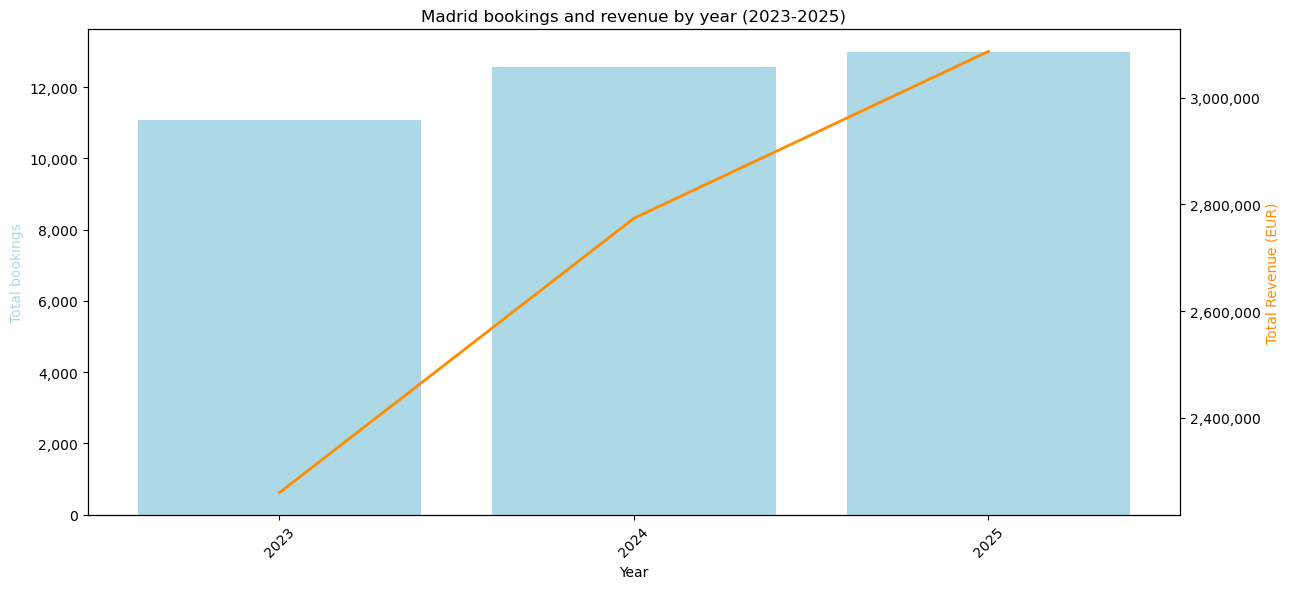

In [9]:
fig, ax1 = plt.subplots(figsize=(13,6))

months = madrid['year'].astype(str)
bookings = madrid['total_bookings']
revenues = madrid['total_revenue']

ax1.bar(months, bookings, color='lightblue')
ax1.set_title("Madrid bookings and revenue by year (2023-2025)")
ax1.set_xlabel("Year")
ax1.set_ylabel("Total bookings", color='lightblue')
ax1.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))

plt.xticks(rotation=45)

ax2 = ax1.twinx()

ax2.plot(ax1.get_xticks(), revenues, color='darkorange', linewidth=2)
ax2.set_ylabel('Total Revenue (EUR)', color='darkorange')
ax2.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))

fig.tight_layout()
plt.show()

In [10]:
# Calculate growth rates
madrid['bookings_growth_pct'] = madrid['total_bookings'].pct_change() * 100
madrid['revenue_growth_pct'] = madrid['total_revenue'].pct_change() * 100

# Formatting
madrid.style.format({
    'total_bookings': '{:,.0f}',
    'total_revenue': '{:,.0f}',
    'bookings_growth_pct': '{:.1f}%',
    'revenue_growth_pct': '{:.1f}%'
})

,year,total_bookings,total_revenue,bookings_growth_pct,revenue_growth_pct
0,2023,"11,085","2,259,916",nan%,nan%
1,2024,"12,570","2,774,154",13.4%,22.8%
2,2025,"12,970","3,086,915",3.2%,11.3%


In [11]:
### Madrid data

madrid_customers = run("""
    SELECT
        year,
        SUM(available_listings) AS total_available_listings,
        SUM(visitors) AS total_visitors
    FROM df
    WHERE city = 'Madrid'
    GROUP BY year
    ORDER BY year
""")

madrid_customers

,year,total_available_listings,total_visitors
0,2023,25934.0,593310.0
1,2024,35837.0,769134.0
2,2025,45518.0,936254.0


In [12]:
# Calculate growth rates
madrid_customers['available_listings_growth_pct'] = madrid_customers['total_available_listings'].pct_change() * 100
madrid_customers['visitors_growth_pct'] = madrid_customers['total_visitors'].pct_change() * 100

# Formatting
madrid_customers.style.format({
    'total_available_listings': '{:,.0f}',
    'total_visitors': '{:,.0f}',
    'available_listings_growth_pct': '{:.1f}%',
    'visitors_growth_pct': '{:.1f}%'
})

,year,total_available_listings,total_visitors,available_listings_growth_pct,visitors_growth_pct
0,2023,"25,934","593,310",nan%,nan%
1,2024,"35,837","769,134",38.2%,29.6%
2,2025,"45,518","936,254",27.0%,21.7%


In [13]:
### Madrid monthly data

madrid_monthly = run("""
    SELECT
        full_date,
        SUM(bookings) AS total_bookings,
        SUM(revenue_eur) AS total_revenue
    FROM df
    WHERE city = 'Madrid'
    GROUP BY full_date
    ORDER BY full_date
""")

#madrid.shape

madrid_monthly

,full_date,total_bookings,total_revenue
0,2023-01-01,1066.0,206137.0
1,2023-02-01,1113.0,232303.0
2,2023-03-01,1095.0,211969.0
3,2023-04-01,1075.0,206471.0
4,2023-05-01,1003.0,210413.0
5,2023-06-01,611.0,121806.0
6,2023-07-01,531.0,104464.0
7,2023-08-01,547.0,110952.0
8,2023-09-01,1086.0,233413.0
9,2023-10-01,1035.0,218425.0


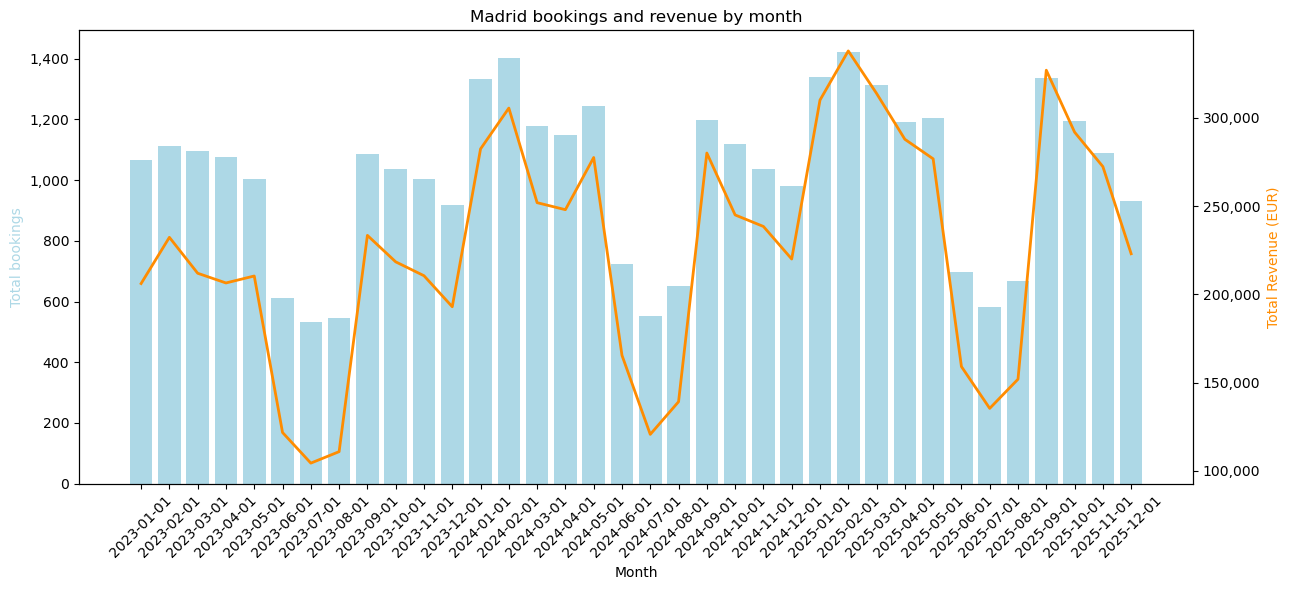

In [14]:
fig, ax1 = plt.subplots(figsize=(13,6))

months = madrid_monthly['full_date'].astype(str)
bookings = madrid_monthly['total_bookings']
revenues = madrid_monthly['total_revenue']

ax1.bar(months, bookings, color='lightblue')
ax1.set_title("Madrid bookings and revenue by month")
ax1.set_xlabel("Month")
ax1.set_ylabel("Total bookings", color='lightblue')
ax1.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))

plt.xticks(rotation=45)

ax2 = ax1.twinx()

ax2.plot(ax1.get_xticks(), revenues, color='darkorange', linewidth=2)
ax2.set_ylabel('Total Revenue (EUR)', color='darkorange')
ax2.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))

fig.tight_layout()
plt.show()

### Insights:

#### Growth in Madrid is positive in terms of total # of <u>bookings per year</u> and <u>total revenue</u>
* Total bookings grew at 13.4% from 2023 to 2024, and only at 3.2% thereafter
* Total revenue grew at 22.8% from 2023 to 2024, and only at 11.3% thereafter

#### Growth in bookings and total revenue is due to both <u>growth in visitors</u> and <u>available listings</u>
* Total available listings grew at 38.2% from 2023 to 2024, and at 27% thereafter
* Total revenue grew at 29.6% from 2023 to 2024, and only at 21.7% thereafter

#### On a monthly basis, there is some seasonality - bookings and total revenue go down in the summer months (May to August)

## Q2: What is happening in the summer months?

### Q2.1: What is happening overall?

In [15]:
### Madrid data grouped by listing type and landlord type
# Checking January data to see if it matches

madrid_by_listing_landlord = run("""
    SELECT
        full_date,
        listing_type,
        landlord_type,
        SUM(bookings) AS total_bookings,
        SUM(revenue_eur) AS total_revenue
    FROM df
    WHERE city = 'Madrid'
    GROUP BY full_date, listing_type, landlord_type
    ORDER BY full_date
""")

#madrid.shape

madrid_by_listing_landlord

,full_date,listing_type,landlord_type,total_bookings,total_revenue
0,2023-01-01,Apartment,Private Landlord,242.0,66315.0
1,2023-01-01,Room,PBSA,42.0,5270.0
2,2023-01-01,Apartment,PBSA,0.0,0.0
3,2023-01-01,Apartment,Property Manager,120.0,33260.0
4,2023-01-01,Studio,PBSA,31.0,4803.0
...,...,...,...,...,...
319,2025-12-01,Room,Property Manager,77.0,12695.0
320,2025-12-01,Studio,PBSA,27.0,4934.0
321,2025-12-01,Room,Private Landlord,190.0,30973.0
322,2025-12-01,Studio,Private Landlord,182.0,38270.0


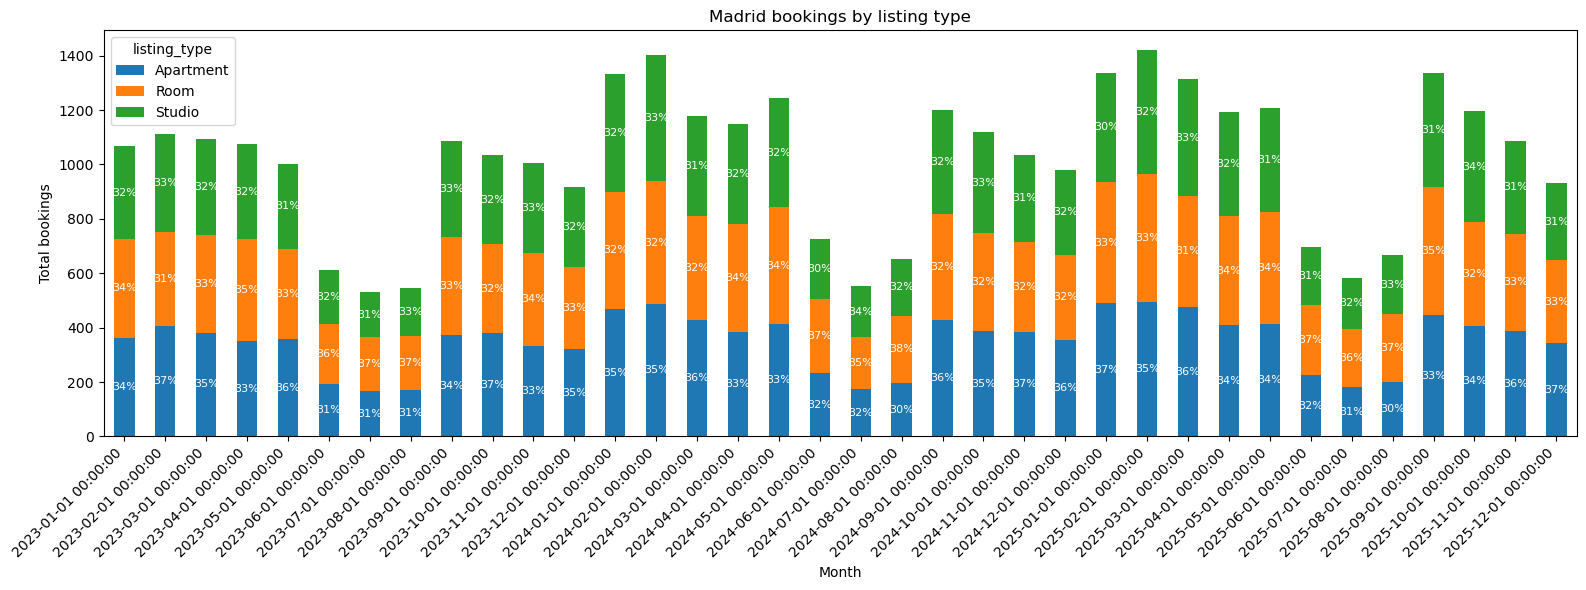

In [16]:
### Plot by listing_type 

pivot = madrid_by_listing_landlord.pivot_table(
    index = 'full_date',
    columns = 'listing_type',
    values = 'total_bookings',
    aggfunc = 'sum'
)

fig, ax = plt.subplots(figsize = (16, 6))

pivot.plot(kind='bar', stacked=True, ax=ax)
ax.set_title("Madrid bookings by listing type")
ax.set_xlabel("Month")
ax.set_ylabel("Total bookings")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

totals = pivot.sum(axis=1)
for bar_group in ax.containers:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:
            pct = height / totals.iloc[int(bar.get_x() + bar.get_width() / 2 + 0.5)]
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2,
                f'{pct:.0%}',
                ha='center', va='center', fontsize=8, color='white'
            )


plt.show()

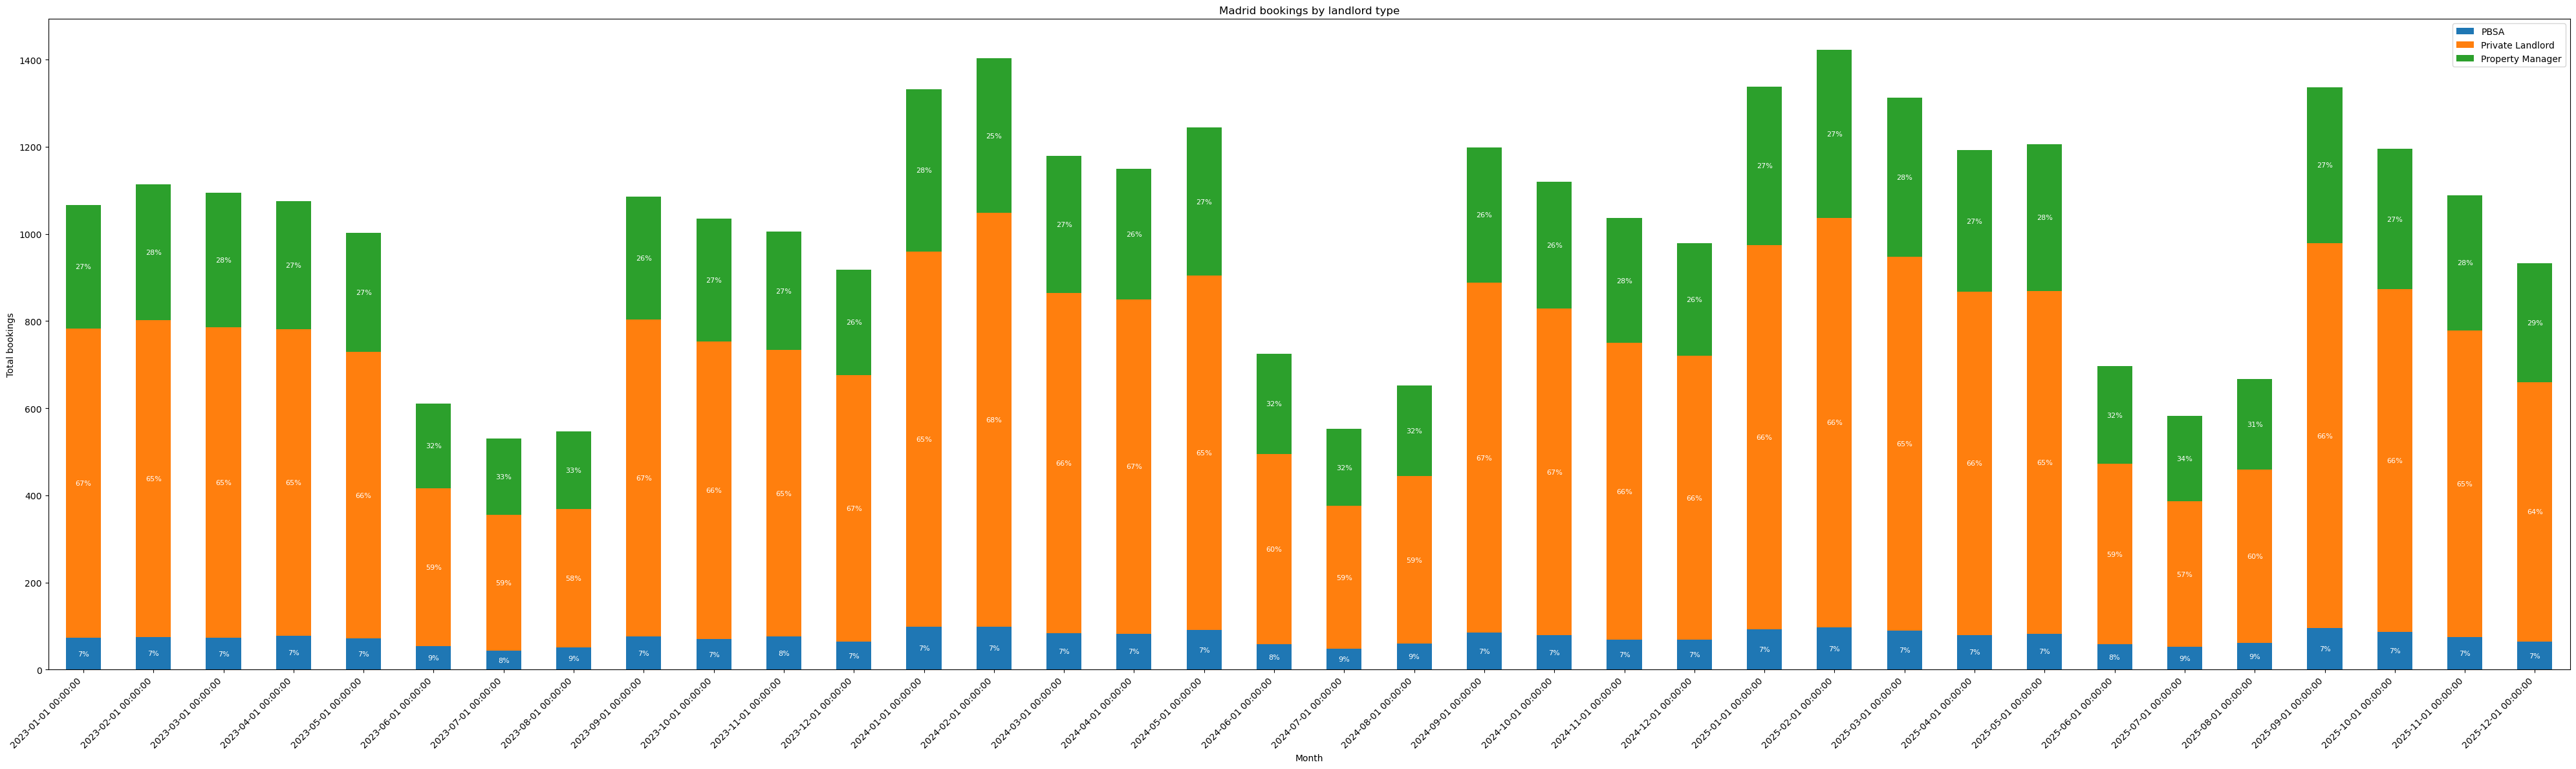

In [17]:
### Plot by listing_type 

pivot = madrid_by_listing_landlord.pivot_table(
    index = 'full_date',
    columns = 'landlord_type',
    values = 'total_bookings',
    aggfunc = 'sum'
)

fig, ax = plt.subplots(figsize = (40, 12))

pivot.plot(kind='bar', stacked=True, ax=ax)
ax.set_title("Madrid bookings by landlord type")
ax.set_xlabel("Month")
ax.set_ylabel("Total bookings")
plt.legend(loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

totals = pivot.sum(axis=1)
for bar_group in ax.containers:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:
            pct = height / totals.iloc[int(bar.get_x() + bar.get_width() / 2 + 0.5)]
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2,
                f'{pct:.0%}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.show()

### Insights:

#### In terms of <u>listing type</u>, the share of apartments vs rooms vs studios is steady during the summer months
* Each type of accomodation is about 1/3 of total listings and this is steady throughout the year

#### In terms of <u>landlord type</u>, there is a drop in the bookings for private landlords over the summer months (June to August)
* Likely because private landlords are taking more advantage of shorter-term listings to take advantage of increased tourism in the summer

### Q2.2: What is happening across different landlord types?

In [18]:
## Create a reusable function to get data based on landlord type
def create_data_by_landlord_type(landlord_type):

    data = run(f"""
        SELECT
            year,
            month,
            SUM(available_listings) as total_available_listings
        FROM df
        WHERE city = 'Madrid'
        AND landlord_type = '{landlord_type}'
        GROUP BY year, month
        ORDER BY year, month
    """)

    pivot = data.pivot(index = 'year', columns = 'month', values = 'total_available_listings')
    indexed = pivot.div(pivot[1], axis=0) * 100

    return (pivot, indexed)

In [19]:
pivot_private_landlord, indexed_private_landlord = create_data_by_landlord_type('Private Landlord')
pivot_private_landlord

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2023,1525.0,1606.0,1601.0,1701.0,1735.0,890.0,947.0,954.0,1871.0,2014.0,1981.0,2005.0
2024,2105.0,2129.0,2139.0,2268.0,2224.0,1131.0,1163.0,1231.0,2451.0,2538.0,2552.0,2614.0
2025,2537.0,2697.0,2677.0,2715.0,2712.0,1360.0,1457.0,1410.0,2840.0,2893.0,2913.0,2994.0


In [20]:
indexed_private_landlord.style.format("{:.1f}")

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2023,100.0,105.3,105.0,111.5,113.8,58.4,62.1,62.6,122.7,132.1,129.9,131.5
2024,100.0,101.1,101.6,107.7,105.7,53.7,55.2,58.5,116.4,120.6,121.2,124.2
2025,100.0,106.3,105.5,107.0,106.9,53.6,57.4,55.6,111.9,114.0,114.8,118.0


In [21]:
def create_available_listings_linechart(indexed, label, marker):

    fig, ax = plt.subplots(figsize=(10,5))

    for year in indexed.index:
        ax.plot(indexed.columns, indexed.loc[year], marker=marker, label=str(year))

    ax.axhline(100, color='grey', linestyle='--', linewidth=0.8)
    ax.set_title(label + ' Available Listings - Indexed (Jan = 100)')
    ax.set_xlabel('Month')
    ax.set_ylabel('Index')
    ax.legend(title='Year')
    plt.tight_layout()
    return fig, ax

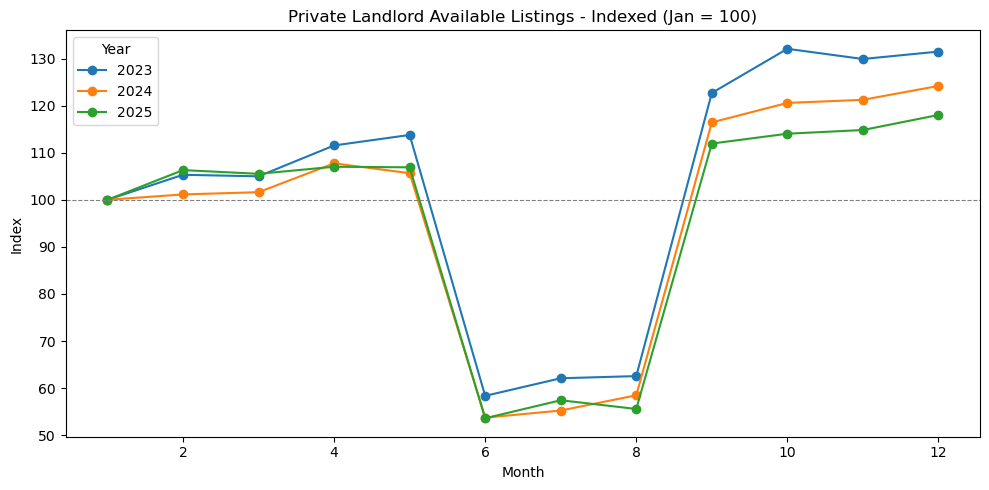

In [22]:
fig, ax = create_available_listings_linechart(indexed_private_landlord, 'Private Landlord', 'o')
plt.show()

In [23]:
pivot_property_manager, indexed_property_manager = create_data_by_landlord_type('Property Manager')
pivot_property_manager

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2023,366.0,383.0,397.0,411.0,452.0,412.0,442.0,483.0,517.0,562.0,584.0,588.0
2024,645.0,657.0,670.0,695.0,741.0,707.0,696.0,736.0,866.0,871.0,880.0,963.0
2025,966.0,998.0,1017.0,1088.0,1084.0,992.0,1029.0,1126.0,1204.0,1220.0,1328.0,1322.0


In [24]:
indexed_property_manager.style.format("{:.1f}")

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2023,100.0,104.6,108.5,112.3,123.5,112.6,120.8,132.0,141.3,153.6,159.6,160.7
2024,100.0,101.9,103.9,107.8,114.9,109.6,107.9,114.1,134.3,135.0,136.4,149.3
2025,100.0,103.3,105.3,112.6,112.2,102.7,106.5,116.6,124.6,126.3,137.5,136.9


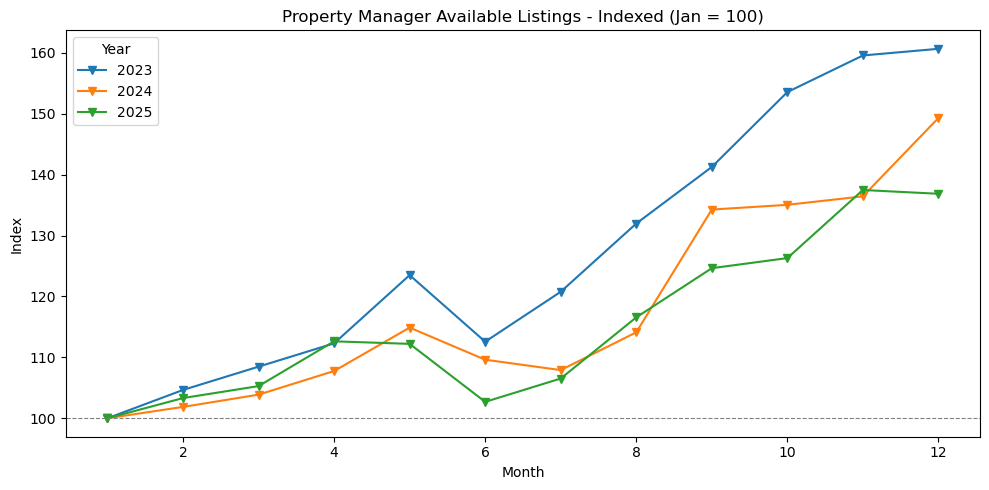

In [25]:
fig, ax = create_available_listings_linechart(indexed_property_manager, 'Property Manager', 'v')
plt.show()

In [26]:
pivot_pbsa, indexed_pbsa = create_data_by_landlord_type('PBSA')
pivot_pbsa

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2023,103.0,108.0,109.0,113.0,116.0,125.0,127.0,129.0,133.0,146.0,146.0,152.0
2024,154.0,154.0,167.0,173.0,169.0,176.0,183.0,180.0,194.0,205.0,208.0,202.0
2025,207.0,219.0,222.0,236.0,238.0,230.0,246.0,250.0,253.0,279.0,278.0,281.0


In [27]:
indexed_pbsa.style.format("{:.1f}")

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2023,100.0,104.9,105.8,109.7,112.6,121.4,123.3,125.2,129.1,141.7,141.7,147.6
2024,100.0,100.0,108.4,112.3,109.7,114.3,118.8,116.9,126.0,133.1,135.1,131.2
2025,100.0,105.8,107.2,114.0,115.0,111.1,118.8,120.8,122.2,134.8,134.3,135.7


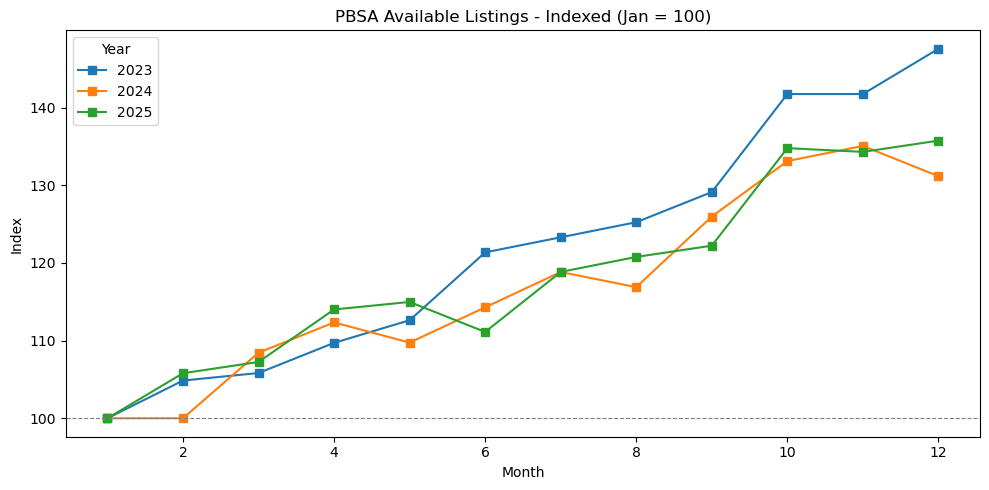

In [28]:
fig, ax = create_available_listings_linechart(indexed_pbsa, 'PBSA', 's')
plt.show()

In [29]:
## Digging into what is happening in terms of demand

madrid_visitors_by_month = run("""
    SELECT
        year,
        month,
        SUM(visitors) as total_visitors
    FROM df
    WHERE city = 'Madrid'
    GROUP BY year, month
    ORDER BY year, month
""")

# madrid_visitors_by_month

pivot = madrid_visitors_by_month.pivot(index = 'year', columns = 'month', values = 'total_visitors')
pivot

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2023,43544.0,47026.0,45174.0,44236.0,45445.0,53395.0,56691.0,60451.0,61198.0,48644.0,46664.0,40842.0
2024,60546.0,65088.0,55992.0,57746.0,60804.0,71184.0,73715.0,78950.0,76062.0,62938.0,54485.0,51624.0
2025,71519.0,81165.0,73082.0,66074.0,74425.0,80707.0,88952.0,94039.0,97110.0,74359.0,72400.0,62422.0


### Insights:

#### Private landlords WITHDRAW summer availability - but they don't actually stop creating listings
* Available (bookable) listings drop ~45% in Jun-Aug every year, then snap back in September (maybe due to academic intake?)
* BUT *created* listings (new postings) do **not** dip in summer - they hold steady / keep rising in 2023–24. So the driver is existing inventory going *unavailable*, as opposed to landlords posting less. This is consistent with units diverted to short-term/tourist lets or booked off-platform over summer
* However: in 2025, *created* listings decline steadily all year (Jan=100 → Dec=65) - not sure if this is an exception or signal of softening in new private-landlord supply

#### Property Manager listings rise modestly but on a much smaller base, so they don't offset the private-landlord drop
* (Based on available listings; the created-vs-available split above was run for Private Landlord only - worth repeating for PM/PBSA)


In [30]:
## Validate the supply story: are listings WITHDRAWN, or just BOOKED AWAY?
## If created_listings ALSO drops in summer -> landlords pull back (true supply withdrawal).
## If created holds steady but available falls -> the drop is bookings consuming inventory (different story).
supply_check = run("""
    SELECT
        year, month,
        SUM(created_listings)   AS total_created,
        SUM(available_listings) AS total_available
    FROM df
    WHERE city = 'Madrid' AND landlord_type = 'Private Landlord'
    GROUP BY year, month
    ORDER BY year, month
""")

# Index both to Jan=100 within each year so summer seasonality is comparable across the two series
for col in ['total_created', 'total_available']:
    piv = supply_check.pivot(index='year', columns='month', values=col)
    idx = piv.div(piv[1], axis=0) * 100
    print(f"\n{col} (Jan = 100):")
    display(idx.style.format("{:.0f}"))


total_created (Jan = 100):


month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2023,100,106,120,125,136,139,149,147,157,172,174,186
2024,100,100,108,116,121,127,138,145,164,163,171,178
2025,100,90,93,89,87,87,83,75,77,67,69,65



total_available (Jan = 100):


month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2023,100,105,105,112,114,58,62,63,123,132,130,131
2024,100,101,102,108,106,54,55,58,116,121,121,124
2025,100,106,106,107,107,54,57,56,112,114,115,118


### Q2.3: What is happening to demand?

In [31]:
## Quantify the summer visitors

indexed = pivot.div(pivot[1], axis=0) * 100
indexed.style.format("{:.1f}")

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2023,100.0,108.0,103.7,101.6,104.4,122.6,130.2,138.8,140.5,111.7,107.2,93.8
2024,100.0,107.5,92.5,95.4,100.4,117.6,121.8,130.4,125.6,104.0,90.0,85.3
2025,100.0,113.5,102.2,92.4,104.1,112.8,124.4,131.5,135.8,104.0,101.2,87.3


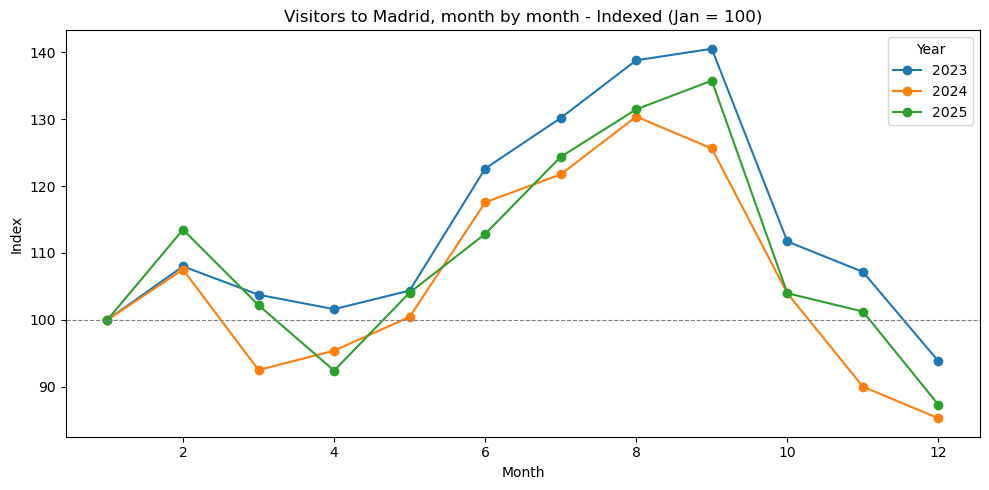

In [32]:
fig, ax = plt.subplots(figsize=(10,5))

for year in indexed.index:
    ax.plot(indexed.columns, indexed.loc[year], marker='o', label=str(year))

ax.axhline(100, color='grey', linestyle='--', linewidth=0.8)
ax.set_title('Visitors to Madrid, month by month - Indexed (Jan = 100)')
ax.set_xlabel('Month')
ax.set_ylabel('Index')
ax.legend(title='Year')
plt.tight_layout()
plt.show()


In [33]:
## Digging into what is happening in terms of searches

searchers = run("""
    SELECT
        year,
        month,
        SUM(searchers) as total_searchers
    FROM df
    WHERE city = 'Madrid'
    GROUP BY year, month
    ORDER BY year, month
""")

# searchers

pivot = searchers.pivot(index = 'year', columns = 'month', values = 'total_searchers')
pivot


month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2023,15850.0,16291.0,16559.0,16098.0,16028.0,19309.0,22041.0,22287.0,20900.0,16946.0,15945.0,15300.0
2024,22017.0,23384.0,20267.0,20291.0,21578.0,25315.0,26334.0,27750.0,26413.0,21134.0,18241.0,18590.0
2025,24897.0,26562.0,24331.0,24002.0,24518.0,27648.0,31452.0,32858.0,33641.0,23479.0,24136.0,20670.0


In [34]:
## Quantify the summer visitors

indexed = pivot.div(pivot[1], axis=0) * 100
indexed.style.format("{:.1f}")

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2023,100.0,102.8,104.5,101.6,101.1,121.8,139.1,140.6,131.9,106.9,100.6,96.5
2024,100.0,106.2,92.1,92.2,98.0,115.0,119.6,126.0,120.0,96.0,82.8,84.4
2025,100.0,106.7,97.7,96.4,98.5,111.0,126.3,132.0,135.1,94.3,96.9,83.0


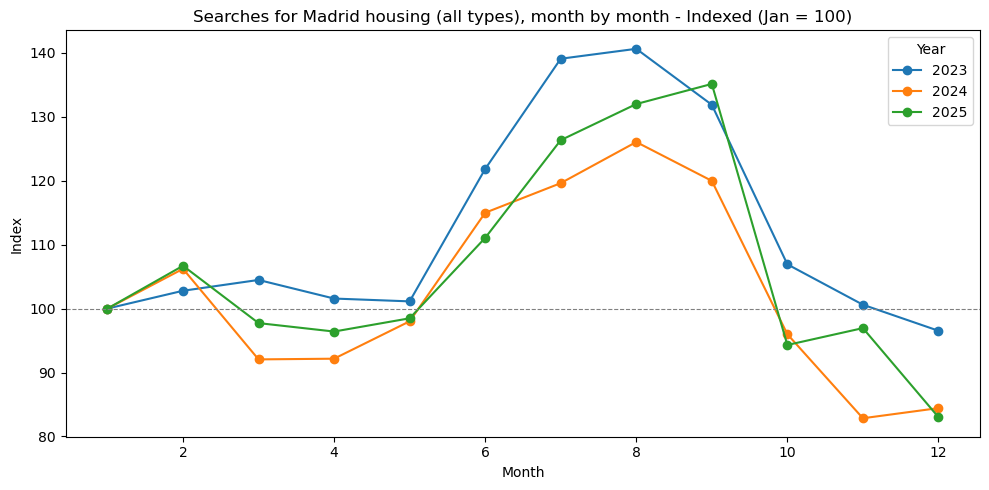

In [35]:
fig, ax = plt.subplots(figsize=(10,5))

for year in indexed.index:
    ax.plot(indexed.columns, indexed.loc[year], marker='o', label=str(year))

ax.axhline(100, color='grey', linestyle='--', linewidth=0.8)
ax.set_title('Searches for Madrid housing (all types), month by month - Indexed (Jan = 100)')
ax.set_xlabel('Month')
ax.set_ylabel('Index')
ax.legend(title='Year')
plt.tight_layout()
plt.show()

## Q3: What is happening across different listing types?

In [36]:
## Create a reusable function to get data based on listing type
def create_data_by_listing_type(listing_type):

    data = run(f"""
        SELECT
            year,
            month,
            SUM(available_listings) as total_available_listings
        FROM df
        WHERE city = 'Madrid'
        AND listing_type = '{listing_type}'
        GROUP BY year, month
        ORDER BY year, month
    """)

    pivot = data.pivot(index = 'year', columns = 'month', values = 'total_available_listings')
    indexed = pivot.div(pivot[1], axis=0) * 100

    return (pivot, indexed)

In [37]:
pivot_room, indexed_room = create_data_by_listing_type('Room')
pivot_room

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2023,738.0,761.0,759.0,834.0,870.0,656.0,700.0,721.0,910.0,1019.0,967.0,976.0
2024,1059.0,1085.0,1038.0,1135.0,1135.0,892.0,914.0,964.0,1222.0,1307.0,1304.0,1356.0
2025,1297.0,1405.0,1351.0,1388.0,1372.0,1081.0,1171.0,1186.0,1446.0,1562.0,1525.0,1583.0


In [38]:
indexed_room.style.format("{:.1f}")

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2023,100.0,103.1,102.8,113.0,117.9,88.9,94.9,97.7,123.3,138.1,131.0,132.2
2024,100.0,102.5,98.0,107.2,107.2,84.2,86.3,91.0,115.4,123.4,123.1,128.0
2025,100.0,108.3,104.2,107.0,105.8,83.3,90.3,91.4,111.5,120.4,117.6,122.1


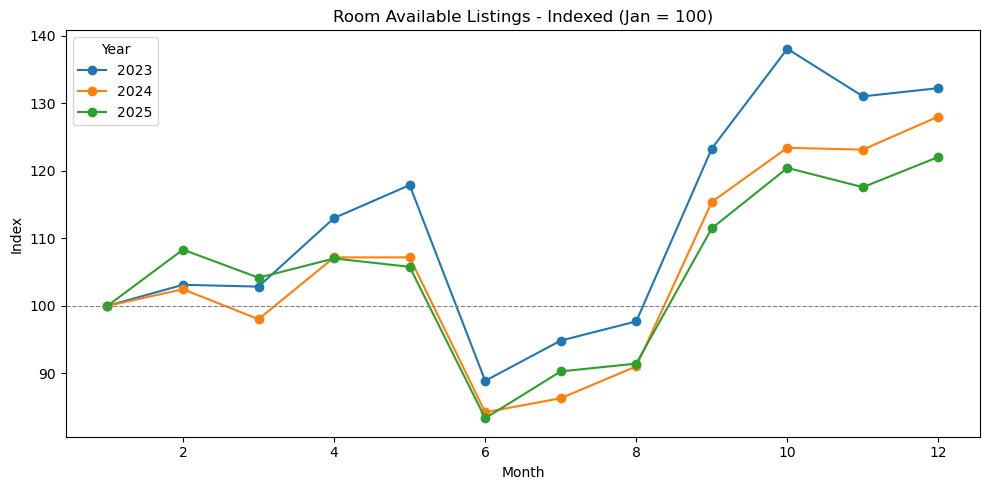

In [39]:
fig, ax = create_available_listings_linechart(indexed_room, 'Room', 'o')
plt.show()

In [40]:
pivot_studio, indexed_studio = create_data_by_listing_type('Studio')
pivot_studio

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2023,617.0,641.0,633.0,673.0,696.0,434.0,450.0,463.0,757.0,772.0,831.0,802.0
2024,865.0,853.0,902.0,935.0,911.0,574.0,581.0,606.0,1030.0,993.0,1061.0,1055.0
2025,1072.0,1143.0,1096.0,1145.0,1110.0,713.0,741.0,755.0,1242.0,1240.0,1293.0,1263.0


In [41]:
indexed_studio.style.format("{:.1f}")

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2023,100.0,103.9,102.6,109.1,112.8,70.3,72.9,75.0,122.7,125.1,134.7,130.0
2024,100.0,98.6,104.3,108.1,105.3,66.4,67.2,70.1,119.1,114.8,122.7,122.0
2025,100.0,106.6,102.2,106.8,103.5,66.5,69.1,70.4,115.9,115.7,120.6,117.8


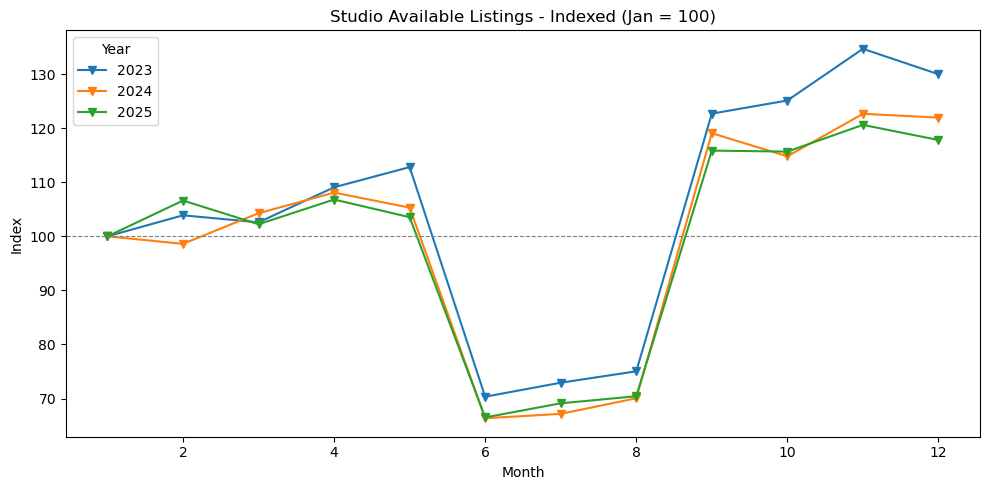

In [42]:
fig, ax = create_available_listings_linechart(indexed_studio, 'Studio', 'v')
plt.show()

In [43]:
pivot_apartment, indexed_apartment = create_data_by_listing_type('Apartment')
pivot_apartment

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2023,639.0,695.0,715.0,718.0,737.0,337.0,366.0,382.0,854.0,931.0,913.0,967.0
2024,980.0,1002.0,1036.0,1066.0,1088.0,548.0,547.0,577.0,1259.0,1314.0,1275.0,1368.0
2025,1341.0,1366.0,1469.0,1506.0,1552.0,788.0,820.0,845.0,1609.0,1590.0,1701.0,1751.0


In [44]:
indexed_apartment.style.format("{:.1f}")

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2023,100.0,108.8,111.9,112.4,115.3,52.7,57.3,59.8,133.6,145.7,142.9,151.3
2024,100.0,102.2,105.7,108.8,111.0,55.9,55.8,58.9,128.5,134.1,130.1,139.6
2025,100.0,101.9,109.5,112.3,115.7,58.8,61.1,63.0,120.0,118.6,126.8,130.6


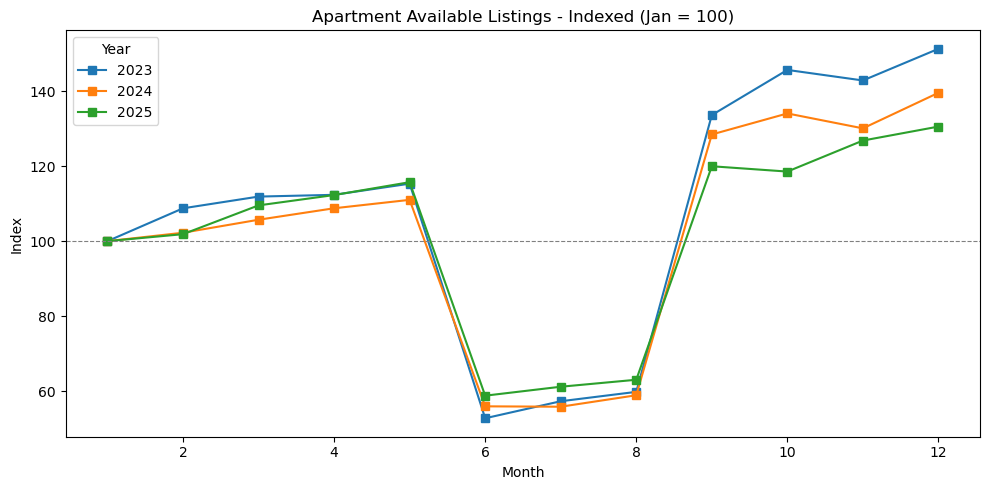

In [45]:
fig, ax = create_available_listings_linechart(indexed_apartment, 'Apartment', 's')
plt.show()

## Q4: What is happening in the funnel?

In [46]:
## Digging into what is happening in terms of demand funnel 
## Taking 2025 as an example to simplify. If I had more time, I could also use the average of the last 3 years

demand_funnel = run("""
    SELECT
        full_date,
        year,
        month,
        SUM(searchers) as total_searchers,
        SUM(applicants) as total_applicants,
        SUM(bookings) as total_bookings
    FROM df
    WHERE city = 'Madrid' and year = '2025'
    GROUP BY full_date, year, month
    ORDER BY full_date, year, month
""")

demand_funnel

,full_date,year,month,total_searchers,total_applicants,total_bookings
0,2025-01-01,2025,1,24897.0,5652.0,1338.0
1,2025-02-01,2025,2,26562.0,6103.0,1422.0
2,2025-03-01,2025,3,24331.0,5555.0,1313.0
3,2025-04-01,2025,4,24002.0,5217.0,1192.0
4,2025-05-01,2025,5,24518.0,5276.0,1206.0
5,2025-06-01,2025,6,27648.0,4305.0,697.0
6,2025-07-01,2025,7,31452.0,3905.0,583.0
7,2025-08-01,2025,8,32858.0,4459.0,667.0
8,2025-09-01,2025,9,33641.0,6267.0,1337.0
9,2025-10-01,2025,10,23479.0,5241.0,1195.0


In [47]:
# Funnel conversion rates 
demand_funnel['applicants_per_searcher'] = demand_funnel['total_applicants'] / demand_funnel['total_searchers']
demand_funnel['bookings_per_applicant'] = demand_funnel['total_bookings']  / demand_funnel['total_applicants']
demand_funnel['bookings_per_searcher'] = demand_funnel['total_bookings']  / demand_funnel['total_searchers']  # full-funnel

demand_funnel.style.format({
    'total_searchers':         '{:,.0f}',
    'total_applicants':        '{:,.0f}',
    'total_bookings':          '{:,.0f}',
    'applicants_per_searcher': '{:.1%}',   
    'bookings_per_applicant':  '{:.1%}',
    'bookings_per_searcher':   '{:.1%}',
})

,full_date,year,month,total_searchers,total_applicants,total_bookings,applicants_per_searcher,bookings_per_applicant,bookings_per_searcher
0,2025-01-01 00:00:00,2025,1,"24,897","5,652","1,338",22.7%,23.7%,5.4%
1,2025-02-01 00:00:00,2025,2,"26,562","6,103","1,422",23.0%,23.3%,5.4%
2,2025-03-01 00:00:00,2025,3,"24,331","5,555","1,313",22.8%,23.6%,5.4%
3,2025-04-01 00:00:00,2025,4,"24,002","5,217","1,192",21.7%,22.8%,5.0%
4,2025-05-01 00:00:00,2025,5,"24,518","5,276","1,206",21.5%,22.9%,4.9%
5,2025-06-01 00:00:00,2025,6,"27,648","4,305",697,15.6%,16.2%,2.5%
6,2025-07-01 00:00:00,2025,7,"31,452","3,905",583,12.4%,14.9%,1.9%
7,2025-08-01 00:00:00,2025,8,"32,858","4,459",667,13.6%,15.0%,2.0%
8,2025-09-01 00:00:00,2025,9,"33,641","6,267","1,337",18.6%,21.3%,4.0%
9,2025-10-01 00:00:00,2025,10,"23,479","5,241","1,195",22.3%,22.8%,5.1%


### Insights:

#### Typical funnel is ~25% of searches result in an application, ~20% of applications result in a booking
* On average from January to December - however, some months are outliers

#### In summer months searchers rise but conversions to bookings fall dramatically, to ~15%
* From June to August, searchings are higher than non-summer months but applicants collapse to only ~15% of searchers compared to 20% in other months
* Conversions from applicants to actual bookings is also reduced by a comparable pattern

## Q5: What is the revenue impact?

#### Trigger
* Given that:
  1) searches are higher in summer than in non-summer seasons and
  2) conversion rates to actual bookings drops in the summer,
* There is likely lost revenue caused by lack of supply 

In [48]:
# Lost-revenue estimate as a bounded range 
# Key assumption: the UPPER bound assumes summer searchers convert at non-summer rates.
# That is an upper bound because some summer demand is likely lower-intent (short-stay/tourist)
# and would not convert at winter rates regardless of supply. The LOWER bound controls for this by
# fixing only the applicant->booking step on the applicants we ACTUALLY got in summer.

summer_months = [6, 7, 8]

# Baseline 1 (UPPER): full-funnel searcher->booking rate from non-summer months
non_summer = demand_funnel[~demand_funnel['month'].isin(summer_months)]
base_conv_searcher = non_summer['total_bookings'].sum() / non_summer['total_searchers'].sum()

# Baseline 2 (LOWER / intent-controlled): applicant->booking rate, strips out low-intent top-of-funnel
base_conv_applicant = non_summer['total_bookings'].sum() / non_summer['total_applicants'].sum()

# Revenue per booking (non-summer avg)
madrid_monthly['avg_rev_per_booking'] = madrid_monthly['total_revenue'] / madrid_monthly['total_bookings']
base_rev = madrid_monthly[~madrid_monthly['full_date'].dt.month.isin(summer_months)]['avg_rev_per_booking'].mean()

summer = demand_funnel[demand_funnel['month'].isin(summer_months)].copy()

# Upper bound: assume summer searchers had winter intent
summer['expected_bookings_upper'] = summer['total_searchers'] * base_conv_searcher
# Lower bound: only fix the applicant->booking step on the applicants we actually got
summer['expected_bookings_lower'] = summer['total_applicants'] * base_conv_applicant

summer['lost_bookings_upper'] = (summer['expected_bookings_upper'] - summer['total_bookings']).clip(lower=0)
summer['lost_bookings_lower'] = (summer['expected_bookings_lower'] - summer['total_bookings']).clip(lower=0)
summer['lost_rev_upper'] = summer['lost_bookings_upper'] * base_rev
summer['lost_rev_lower'] = summer['lost_bookings_lower'] * base_rev

summer[['month', 'total_searchers', 'total_applicants', 'total_bookings',
        'expected_bookings_lower', 'expected_bookings_upper',
        'lost_rev_lower', 'lost_rev_upper']]

,month,total_searchers,total_applicants,total_bookings,expected_bookings_lower,expected_bookings_upper,lost_rev_lower,lost_rev_upper
5,6,27648.0,4305.0,697.0,982.810351,1347.106137,63410.424516,144233.775802
6,7,31452.0,3905.0,583.0,891.492316,1532.450167,68442.688133,210646.807882
7,8,32858.0,4459.0,667.0,1017.967795,1600.955348,77866.378025,207209.097938


In [49]:
print(f"Baseline searcher->booking (non-summer):  {base_conv_searcher:.1%}")
print(f"Baseline applicant->booking (non-summer): {base_conv_applicant:.1%}")
print(f"Avg revenue per booking (non-summer):     EUR {base_rev:,.0f}\n")
print(f"Lost bookings:  {summer['lost_bookings_lower'].sum():,.0f} (lower)  ->  {summer['lost_bookings_upper'].sum():,.0f} (upper)")
print(f"Lost revenue:   EUR {summer['lost_rev_lower'].sum():,.0f} (lower)  ->  EUR {summer['lost_rev_upper'].sum():,.0f} (upper)")

Baseline searcher->booking (non-summer):  4.9%
Baseline applicant->booking (non-summer): 22.8%
Avg revenue per booking (non-summer):     EUR 222

Lost bookings:  945 (lower)  ->  2,534 (upper)
Lost revenue:   EUR 209,719 (lower)  ->  EUR 562,090 (upper)


#### Insight
* Summer lost revenue is a **bounded range: ~EUR 0.21M (lower) to ~EUR 0.56M (upper) per year**
  * **Upper (~EUR 562k)** assumes summer searchers convert at the non-summer rate (~4.9% searcher→booking)
  * **Lower (~EUR 210k)** is intent-controlled: it fixes only the applicant→booking step on the summer applicants we actually got (summer applicant→booking falls to ~15% vs ~23% baseline)
* This is a **supply / matching** problem - because commission rates are flat across the period (confirmed below)
* Mechanism: private landlords do **not** create fewer listings in summer - *created* listings hold steady, but *available* (bookable) listings drop ~45% every summer, then jump back for the September intake. Existing inventory is withdrawn from availability (likely to short-term/tourist lets or booked off-platform like on Airbnb/etc)
* Property Manager apartments could backfill (growing faster) but on a small base, so it may take time...

In [50]:
## Digging into commission rates in case that is driving the difference

commission_rates = run("""
    SELECT
        full_date,
        year,
        month,
        landlord_type,
        listing_type,
        commission_rate_pct
    FROM df
    WHERE city = 'Madrid' 
    GROUP BY full_date, year, month, landlord_type, listing_type, commission_rate_pct
    ORDER BY full_date, year, month, landlord_type, listing_type, commission_rate_pct
""")

commission_rates

,full_date,year,month,landlord_type,listing_type,commission_rate_pct
0,2023-01-01,2023,1,PBSA,Apartment,12.0
1,2023-01-01,2023,1,PBSA,Room,12.0
2,2023-01-01,2023,1,PBSA,Studio,12.0
3,2023-01-01,2023,1,Private Landlord,Apartment,14.0
4,2023-01-01,2023,1,Private Landlord,Room,14.0
...,...,...,...,...,...,...
319,2025-12-01,2025,12,Private Landlord,Room,14.0
320,2025-12-01,2025,12,Private Landlord,Studio,14.0
321,2025-12-01,2025,12,Property Manager,Apartment,15.5
322,2025-12-01,2025,12,Property Manager,Room,15.5


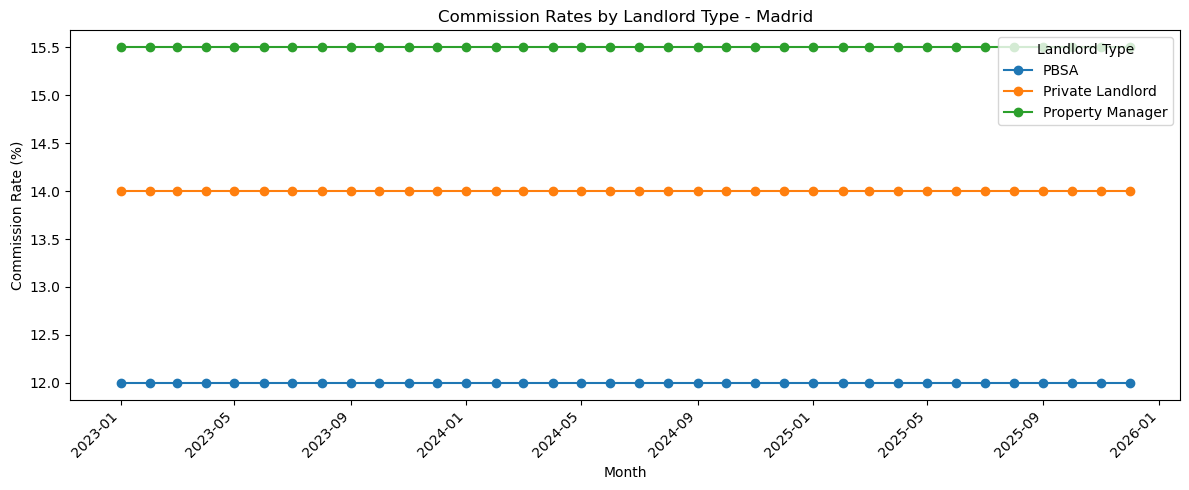

In [51]:
commission_by_landlord = commission_rates.drop_duplicates(
    subset=['full_date', 'landlord_type']
)

fig, ax = plt.subplots(figsize=(12, 5))

for landlord in commission_by_landlord['landlord_type'].unique():
    data = commission_by_landlord[commission_by_landlord['landlord_type'] == landlord]
    ax.plot(data['full_date'], data['commission_rate_pct'], marker='o', label=landlord)

ax.set_title('Commission Rates by Landlord Type - Madrid')
ax.set_xlabel('Month')
ax.set_ylabel('Commission Rate (%)')
ax.legend(title='Landlord Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# FOR VISUALIZATION ONLY - LEVERAGED AI

In [55]:
m = run("""
    SELECT full_date,
           year,
           SUM(searchers) AS searchers,
           SUM(bookings)  AS bookings
    FROM df
    WHERE city = 'Madrid'
    GROUP BY year, full_date
    ORDER BY year, full_date
""")
m

,full_date,year,searchers,bookings
0,2023-01-01,2023,15850.0,1066.0
1,2023-02-01,2023,16291.0,1113.0
2,2023-03-01,2023,16559.0,1095.0
3,2023-04-01,2023,16098.0,1075.0
4,2023-05-01,2023,16028.0,1003.0
5,2023-06-01,2023,19309.0,611.0
6,2023-07-01,2023,22041.0,531.0
7,2023-08-01,2023,22287.0,547.0
8,2023-09-01,2023,20900.0,1086.0
9,2023-10-01,2023,16946.0,1035.0


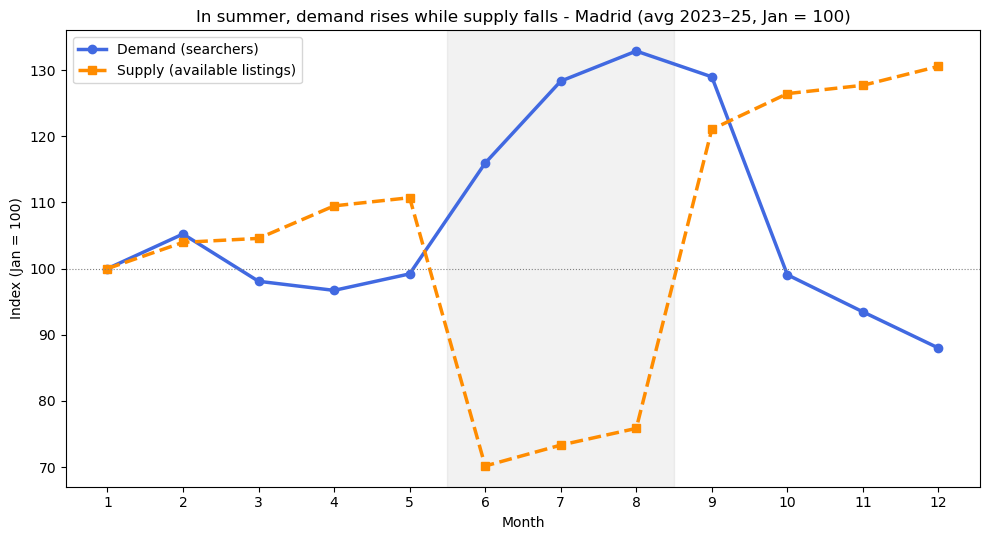

In [56]:
demand_metric = 'searchers'            # demand
supply_metric = 'available_listings'   # supply

def madrid_seasonal(metric):
    d = run(f"""SELECT year, month, SUM({metric}) AS val
                FROM df WHERE city='Madrid'
                GROUP BY year, month ORDER BY year, month""")
    piv = d.pivot(index='year', columns='month', values='val')
    idx = piv.div(piv[1], axis=0) * 100   # index each year to its own Jan=100
    return idx.mean(axis=0)               # average across years -> typical seasonal shape

demand = madrid_seasonal(demand_metric)
supply = madrid_seasonal(supply_metric)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.axvspan(5.5, 8.5, color='grey', alpha=0.10)          # shade summer
ax.plot(demand.index, demand.values, color='royalblue', marker='o',
        linewidth=2.5, label='Demand (searchers)')
ax.plot(supply.index, supply.values, color='darkorange', marker='s',
        linestyle='--', linewidth=2.5, label='Supply (available listings)')
ax.axhline(100, color='grey', linestyle=':', linewidth=0.8)
ax.set_xticks(range(1, 13))
ax.set_title('In summer, demand rises while supply falls - Madrid (avg 2023–25, Jan = 100)')
ax.set_xlabel('Month')
ax.set_ylabel('Index (Jan = 100)')
ax.legend()
plt.tight_layout()
plt.show()

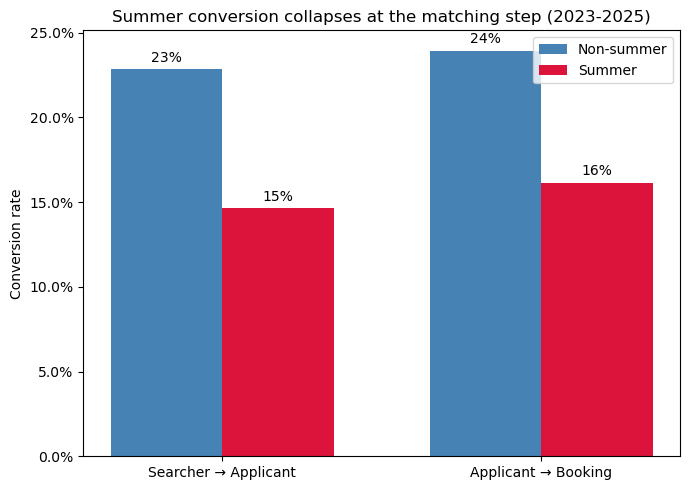

In [68]:
import numpy as np

f = run("""
    SELECT full_date,
           SUM(searchers)  AS searchers,
           SUM(applicants) AS applicants,
           SUM(bookings)   AS bookings
    FROM df WHERE city = 'Madrid'
    GROUP BY full_date
""")
f['season'] = f['full_date'].dt.month.apply(lambda x: 'Summer' if x in (6, 7, 8) else 'Non-summer')

# pooled rates per season (sum then divide — less noisy than averaging monthly rates)
g = f.groupby('season')[['searchers', 'applicants', 'bookings']].sum()
g['Searcher → Applicant'] = g['applicants'] / g['searchers']
g['Applicant → Booking']  = g['bookings']   / g['applicants']
rates = g[['Searcher → Applicant', 'Applicant → Booking']].T   # rows = steps, cols = seasons

steps = rates.index.tolist()
x = np.arange(len(steps)); w = 0.35
fig, ax = plt.subplots(figsize=(7, 5))
b1 = ax.bar(x - w/2, rates['Non-summer'], w, label='Non-summer', color='steelblue')
b2 = ax.bar(x + w/2, rates['Summer'],     w, label='Summer',     color='crimson')

ax.set_xticks(x); ax.set_xticklabels(steps)
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1))
ax.set_ylabel('Conversion rate')
ax.set_title('Summer conversion collapses at the matching step (2023-2025)')
ax.legend()
ax.bar_label(b1, labels=[f'{v:.0%}' for v in rates['Non-summer']], padding=3)
ax.bar_label(b2, labels=[f'{v:.0%}' for v in rates['Summer']],     padding=3)
plt.tight_layout(); plt.show()

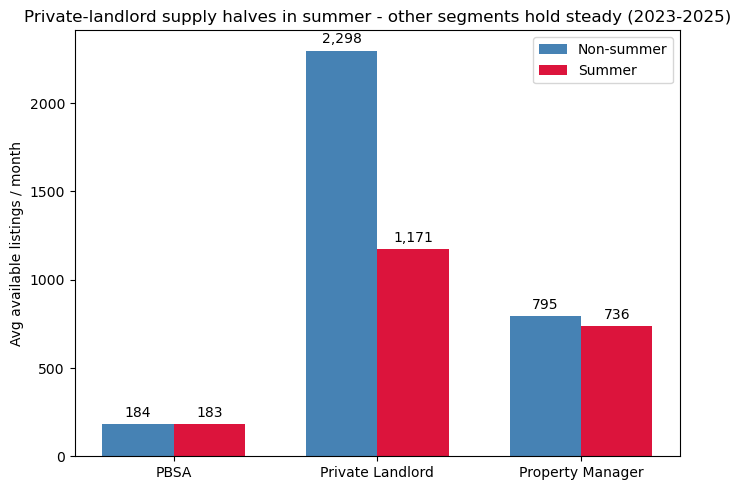

In [67]:
s = run("""
    SELECT full_date, landlord_type,
           SUM(available_listings) AS available
    FROM df WHERE city = 'Madrid'
    GROUP BY full_date, landlord_type
""")
s['season'] = s['full_date'].dt.month.apply(lambda x: 'Summer' if x in (6, 7, 8) else 'Non-summer')

# avg monthly available listings per landlord type, per season
piv = (s.groupby(['landlord_type', 'season'])['available'].mean()
         .unstack('season')[['Non-summer', 'Summer']])

types = piv.index.tolist()
x = np.arange(len(types)); w = 0.35
fig, ax = plt.subplots(figsize=(7, 5))
b1 = ax.bar(x - w/2, piv['Non-summer'], w, label='Non-summer', color='steelblue')
b2 = ax.bar(x + w/2, piv['Summer'],     w, label='Summer',     color='crimson')

ax.set_xticks(x); ax.set_xticklabels(types)
ax.set_ylabel('Avg available listings / month')
ax.set_title('Private-landlord supply halves in summer - other segments hold steady (2023-2025)')
ax.legend()
ax.bar_label(b1, labels=[f'{v:,.0f}' for v in piv['Non-summer']], padding=3)
ax.bar_label(b2, labels=[f'{v:,.0f}' for v in piv['Summer']],     padding=3)
plt.tight_layout(); plt.show()

#Optional polish — add the % drop above the private-landlord pair, since that's the headline number:



In [65]:
# for i, t in enumerate(types):
#     drop = piv.loc[t, 'Summer'] / piv.loc[t, 'Non-summer'] - 1
#     ax.annotate(f'{drop:+.0%}', (i, max(piv.loc[t]) ), ha='center', va='bottom',
#                 fontsize=9, color='crimson' if drop < -0.1 else 'grey')

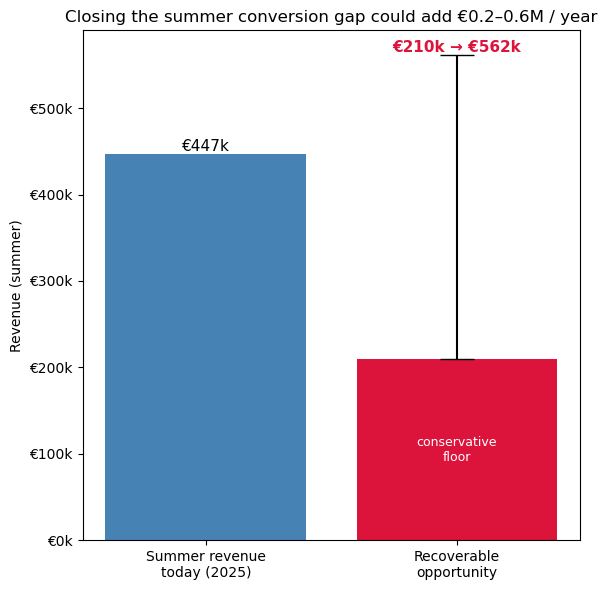

In [69]:
# assumes the corrected lost-revenue cell has been run (so `summer` with lost_rev_lower/upper exists)
lost_low  = summer['lost_rev_lower'].sum()   # ~210k  (intent-controlled floor)
lost_high = summer['lost_rev_upper'].sum()   # ~562k  (searcher-based ceiling)

captured = run("""
    SELECT SUM(revenue_eur) AS rev FROM df
    WHERE city = 'Madrid'
      AND EXTRACT(year  FROM full_date) = 2025
      AND EXTRACT(month FROM full_date) IN (6, 7, 8)
""")['rev'].iloc[0]

fig, ax = plt.subplots(figsize=(6, 6))
ax.bar(0, captured, color='steelblue')
ax.bar(1, lost_low, color='crimson')                       # bar = conservative floor
ax.errorbar(1, lost_low, yerr=[[0], [lost_high - lost_low]],  # cap = upside to ceiling
            fmt='none', ecolor='black', capsize=12, lw=1.5)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Summer revenue\ntoday (2025)', 'Recoverable\nopportunity'])
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f'€{v/1e3:.0f}k'))
ax.set_ylabel('Revenue (summer)')
ax.set_title('Closing the summer conversion gap could add €0.2–0.6M / year')

ax.text(0, captured, f'€{captured/1e3:.0f}k', ha='center', va='bottom', fontsize=11)
ax.text(1, lost_high, f'€{lost_low/1e3:.0f}k → €{lost_high/1e3:.0f}k',
        ha='center', va='bottom', fontsize=11, color='crimson', fontweight='bold')
ax.text(1, lost_low/2, 'conservative\nfloor', ha='center', va='center',
        color='white', fontsize=9)
plt.tight_layout(); plt.show()